In [1]:
from pathlib import Path
import sys
import importlib

# Detect project root
PROJECT_ROOT = Path.cwd()

# If notebook is inside AO/notebooks, move one level up
if not (PROJECT_ROOT / "zernike.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import zernike
import phase_screen
import reconstruction
import psf_tools

importlib.reload(zernike)
importlib.reload(phase_screen)
importlib.reload(reconstruction)
importlib.reload(psf_tools)

from zernike import (
    make_pupil_grid,
    generate_zernike_modes,
)

from phase_screen import fourier_phase_screen

from reconstruction import (
    build_response_matrix,
    measure_slopes,
    reconstruct_wavefront,
    residual_wavefront,
    rms,
)

from psf_tools import (
    compute_psf_from_phase,
    strehl_ratio,
)

In [3]:
# -------------------------
# Basic simulation parameters
# -------------------------
N = 256
diameter = 1.0

# -------------------------
# Pupil grid
# -------------------------
X, Y, rho, theta, mask, dx = make_pupil_grid(
    N=N,
    diameter=diameter,
)

# -------------------------
# Atmospheric phase screen
# -------------------------
W_atm, _, _, _ = fourier_phase_screen(
    N=N,
    delta=dx,
    r0=0.20,
    L0=25.0,
    diameter=diameter,
    seed=4,
    target_rms_rad=1.0,
)

print(f"Atmospheric wavefront RMS: {rms(W_atm, mask):.4f} rad")

Atmospheric wavefront RMS: 0.9999 rad


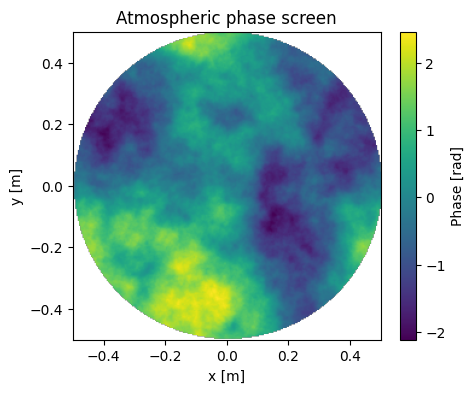

In [4]:
plt.figure(figsize=(5, 4))
plt.imshow(
    W_atm,
    extent=[
        np.nanmin(X),
        np.nanmax(X),
        np.nanmin(Y),
        np.nanmax(Y),
    ],
    origin="lower",
)
plt.colorbar(label="Phase [rad]")
plt.title("Atmospheric phase screen")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.show()

In [5]:
def run_modal_reconstruction_with_max_order(
    W_true,
    X,
    Y,
    rho,
    theta,
    mask,
    max_radial_order,
    n_lenslets=20,
    noise_std=0.0,
    seed=1,
    rcond=1e-4,
):
    """
    Reconstruct wavefront using Zernike modes up to max_radial_order.
    """
    modes = generate_zernike_modes(
        rho,
        theta,
        mask,
        max_radial_order=max_radial_order,
        include_piston=False,
        normalization=True,
    )

    centers, slopes = measure_slopes(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=0.5,
        noise_std=noise_std,
        seed=seed,
    )

    A, names, _ = build_response_matrix(
        modes,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=0.5,
    )

    coeffs, W_rec, residuals, rank, singular_values = reconstruct_wavefront(
        slopes,
        A,
        modes,
        names,
        mask,
        rcond=rcond,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    if singular_values[-1] > 0:
        condition_number = singular_values[0] / singular_values[-1]
    else:
        condition_number = np.inf

    return {
        "modes": modes,
        "names": names,
        "coeffs": coeffs,
        "centers": centers,
        "slopes": slopes,
        "A": A,
        "W_rec": W_rec,
        "residual": res,
        "input_rms": rms(W_true, mask),
        "residual_rms": rms(res, mask),
        "rank": rank,
        "singular_values": singular_values,
        "condition_number": condition_number,
        "n_modes": len(names),
    }

In [6]:
lenslet_values = np.array([8, 10, 12, 14, 16, 20, 24])
max_orders = np.array([2, 3, 4, 5, 6, 7, 8, 9, 10])

noise_std = 0.0
rcond = 1e-4

residual_map = np.zeros((len(max_orders), len(lenslet_values)))
strehl_map = np.zeros_like(residual_map)
condition_map = np.zeros_like(residual_map)
rank_map = np.zeros_like(residual_map)
n_modes_map = np.zeros_like(residual_map)

for i, max_order in enumerate(max_orders):
    for j, n_lens in enumerate(lenslet_values):
        result = run_modal_reconstruction_with_max_order(
            W_atm,
            X,
            Y,
            rho,
            theta,
            mask,
            max_radial_order=int(max_order),
            n_lenslets=int(n_lens),
            noise_std=noise_std,
            seed=1,
            rcond=rcond,
        )

        residual_map[i, j] = result["residual_rms"]
        strehl_map[i, j] = strehl_ratio(
            result["residual"],
            mask,
            pad_factor=4,
        )
        condition_map[i, j] = result["condition_number"]
        rank_map[i, j] = result["rank"]
        n_modes_map[i, j] = result["n_modes"]

        print(
            f"order={max_order:2d}, "
            f"lenslets={n_lens:2d}, "
            f"modes={result['n_modes']:3d}, "
            f"rank={result['rank']:3d}, "
            f"residual={result['residual_rms']:.4f}, "
            f"Strehl={strehl_map[i, j]:.4f}, "
            f"cond={result['condition_number']:.2e}"
        )

order= 2, lenslets= 8, modes=  5, rank=  5, residual=0.8014, Strehl=0.5999, cond=1.50e+00
order= 2, lenslets=10, modes=  5, rank=  5, residual=0.7898, Strehl=0.5959, cond=1.42e+00
order= 2, lenslets=12, modes=  5, rank=  5, residual=0.7880, Strehl=0.5842, cond=1.56e+00
order= 2, lenslets=14, modes=  5, rank=  5, residual=0.7752, Strehl=0.5779, cond=1.38e+00
order= 2, lenslets=16, modes=  5, rank=  5, residual=0.7653, Strehl=0.5704, cond=1.30e+00
order= 2, lenslets=20, modes=  5, rank=  5, residual=0.7561, Strehl=0.5686, cond=1.33e+00
order= 2, lenslets=24, modes=  5, rank=  5, residual=0.7558, Strehl=0.5611, cond=1.45e+00
order= 3, lenslets= 8, modes=  9, rank=  9, residual=0.6886, Strehl=0.6698, cond=2.40e+00
order= 3, lenslets=10, modes=  9, rank=  9, residual=0.6535, Strehl=0.6626, cond=1.98e+00
order= 3, lenslets=12, modes=  9, rank=  9, residual=0.6798, Strehl=0.6867, cond=2.20e+00
order= 3, lenslets=14, modes=  9, rank=  9, residual=0.6713, Strehl=0.6941, cond=1.87e+00
order= 3, 

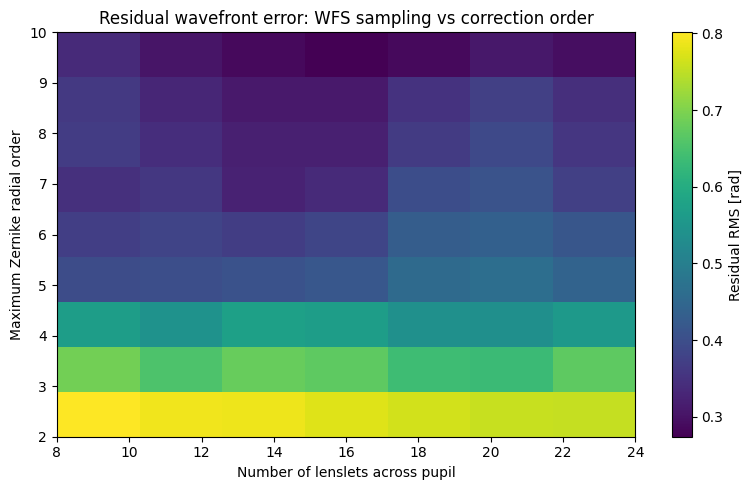

In [7]:
plt.figure(figsize=(8, 5))

im = plt.imshow(
    residual_map,
    origin="lower",
    aspect="auto",
    extent=[
        lenslet_values[0],
        lenslet_values[-1],
        max_orders[0],
        max_orders[-1],
    ],
)

plt.colorbar(im, label="Residual RMS [rad]")
plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Maximum Zernike radial order")
plt.title("Residual wavefront error: WFS sampling vs correction order")

plt.tight_layout()
plt.show()

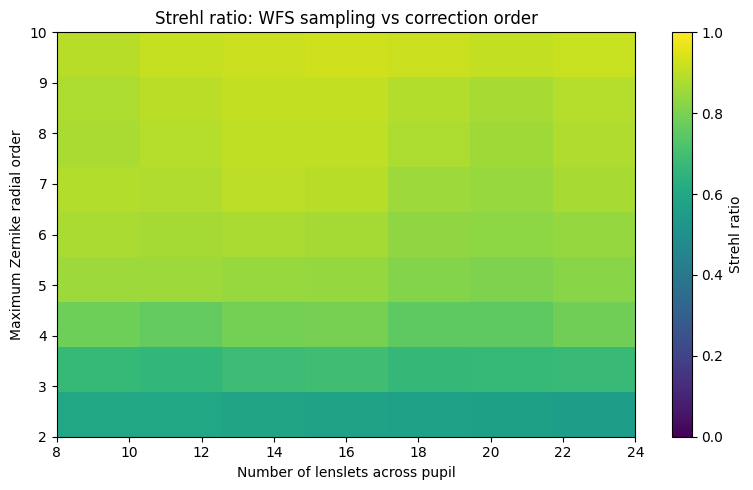

In [8]:
plt.figure(figsize=(8, 5))

im = plt.imshow(
    strehl_map,
    origin="lower",
    aspect="auto",
    extent=[
        lenslet_values[0],
        lenslet_values[-1],
        max_orders[0],
        max_orders[-1],
    ],
    vmin=0,
    vmax=1,
)

plt.colorbar(im, label="Strehl ratio")
plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Maximum Zernike radial order")
plt.title("Strehl ratio: WFS sampling vs correction order")

plt.tight_layout()
plt.show()

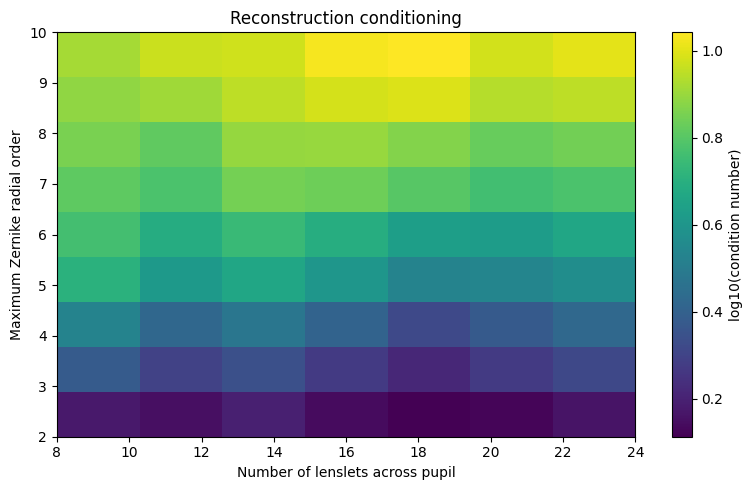

In [9]:
plt.figure(figsize=(8, 5))

im = plt.imshow(
    np.log10(condition_map),
    origin="lower",
    aspect="auto",
    extent=[
        lenslet_values[0],
        lenslet_values[-1],
        max_orders[0],
        max_orders[-1],
    ],
)

plt.colorbar(im, label="log10(condition number)")
plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Maximum Zernike radial order")
plt.title("Reconstruction conditioning")

plt.tight_layout()
plt.show()

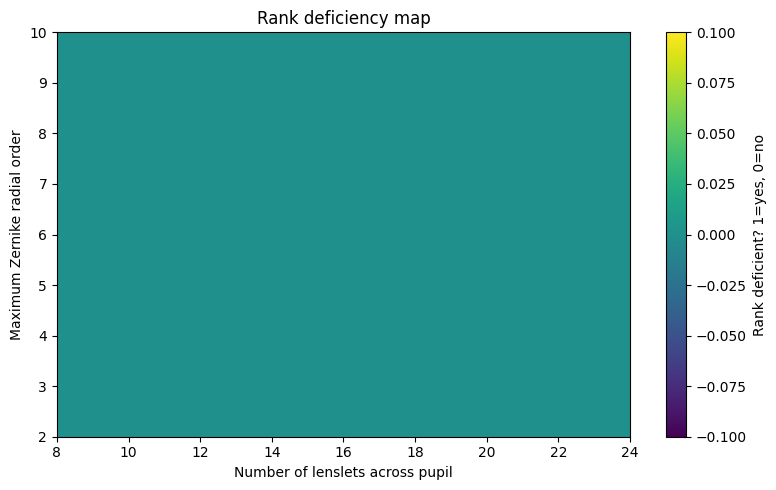

In [10]:
rank_deficient = rank_map < n_modes_map

plt.figure(figsize=(8, 5))

im = plt.imshow(
    rank_deficient,
    origin="lower",
    aspect="auto",
    extent=[
        lenslet_values[0],
        lenslet_values[-1],
        max_orders[0],
        max_orders[-1],
    ],
)

plt.colorbar(im, label="Rank deficient? 1=yes, 0=no")
plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Maximum Zernike radial order")
plt.title("Rank deficiency map")

plt.tight_layout()
plt.show()

## Interpretation: WFS Sampling vs Correction Order

The heatmaps show the trade-off between Shack-Hartmann WFS sampling density and Zernike correction order for the reconstruction of an atmospheric phase screen.

The residual wavefront RMS decreases primarily with increasing maximum Zernike radial order. This indicates that the dominant limitation in this experiment is the finite correction order rather than the number of Shack-Hartmann sub-apertures. Low-order Zernike modes can only remove the large-scale components of the atmospheric phase screen, while higher-order modes can represent progressively smaller spatial structures. Therefore, increasing the reconstruction order reduces the modal fitting error.

The Strehl-ratio heatmap shows the corresponding improvement in focal-plane image quality. As the maximum Zernike order increases, the residual phase error decreases and more optical energy is concentrated back into the diffraction-limited PSF core. This leads to a higher Strehl ratio.

The dependence on the number of lenslets is weaker and not strictly monotonic. In this parameter range, even the lower lenslet numbers provide enough slope measurements to reconstruct the selected Zernike modes. Increasing the number of lenslets improves the WFS sampling, but it does not automatically improve the correction if the reconstruction basis is still limited. In other words, better WFS sampling alone is not equivalent to higher-order AO correction.

The reconstruction-conditioning map shows that the condition number increases with increasing Zernike order. This is expected because higher-order modes contain finer spatial structures and are more difficult to sense robustly with a finite lenslet array. A larger condition number means that the inverse reconstruction becomes more sensitive to measurement noise and numerical errors.

The rank-deficiency map is zero over the full scanned parameter range. This means that, for all tested combinations of lenslet number and Zernike order, the response matrix has full rank and all selected modes are formally observable by the Shack-Hartmann WFS. Therefore, the reconstruction problem is not underdetermined in this scan.


## Extension: Measurement noise sensitivity

The previous heatmaps assumed noiseless slope measurements. In a real Shack-Hartmann WFS, centroid measurements are affected by photon noise, detector noise, finite pixel sampling, and centroiding errors. Here we repeat the sampling-versus-mode-order scan for different slope-noise levels.

The purpose is to test whether high-order modal reconstruction remains useful when the slope measurements are noisy. Since high-order modes are usually associated with smaller singular values of the response matrix, they are expected to be more sensitive to measurement noise.

In [11]:
# Estimate the clean SH-WFS slope scale for each lenslet geometry.
# This is used to interpret absolute noise_std values as relative slope-noise levels.

slope_std_by_lenslet = {}

for nl in lenslet_values:
    centers, slopes_clean = measure_slopes(
        W_atm,
        mask,
        X,
        Y,
        n_lenslets=int(nl),
        min_fill=0.5,
        noise_std=0.0,
    )

    slope_std_by_lenslet[int(nl)] = np.std(slopes_clean)

print("Clean SH-WFS slope standard deviation:")
for nl, std in slope_std_by_lenslet.items():
    print(f"n_lenslets = {nl:2d}: slope std = {std:.4f}")

typical_slope_std = np.mean(list(slope_std_by_lenslet.values()))

print()
print(f"Typical slope std over all tested lenslet geometries: {typical_slope_std:.4f}")

Clean SH-WFS slope standard deviation:
n_lenslets =  8: slope std = 6.8712
n_lenslets = 10: slope std = 7.4030
n_lenslets = 12: slope std = 7.4837
n_lenslets = 14: slope std = 8.5355
n_lenslets = 16: slope std = 9.6034
n_lenslets = 20: slope std = 9.7810
n_lenslets = 24: slope std = 9.9601

Typical slope std over all tested lenslet geometries: 8.5197


In [12]:
def run_sampling_order_scan(
    noise_std,
    seeds,
    use_fast_strehl=True,
):
    """
    Run the lenslet-sampling vs Zernike-order scan for a given absolute
    slope-noise standard deviation.

    The same absolute noise_std is used for all lenslet geometries.
    Its relative strength is interpreted by comparing it with the clean
    SH-WFS slope standard deviation for each lenslet sampling.
    """

    residual_samples = np.zeros(
        (len(seeds), len(max_orders), len(lenslet_values))
    )
    strehl_samples = np.zeros_like(residual_samples)

    condition_map_local = np.zeros((len(max_orders), len(lenslet_values)))
    rank_map_local = np.zeros_like(condition_map_local)
    n_modes_map_local = np.zeros_like(condition_map_local)
    relative_noise_map = np.zeros_like(condition_map_local)

    for k, seed in enumerate(seeds):
        print(f"\nAbsolute noise_std = {noise_std:.3f}, seed = {seed}")

        for i, max_order in enumerate(max_orders):
            for j, n_lens in enumerate(lenslet_values):
                n_lens = int(n_lens)

                result = run_modal_reconstruction_with_max_order(
                    W_atm,
                    X,
                    Y,
                    rho,
                    theta,
                    mask,
                    max_radial_order=int(max_order),
                    n_lenslets=n_lens,
                    noise_std=noise_std,
                    seed=int(seed),
                    rcond=rcond,
                )

                residual_samples[k, i, j] = result["residual_rms"]

                if use_fast_strehl:
                    strehl_samples[k, i, j] = np.exp(
                        -result["residual_rms"]**2
                    )
                else:
                    strehl_samples[k, i, j] = strehl_ratio(
                        result["residual"],
                        mask,
                        pad_factor=4,
                    )

                condition_map_local[i, j] = result["condition_number"]
                rank_map_local[i, j] = result["rank"]
                n_modes_map_local[i, j] = result["n_modes"]

                # Relative noise level for this lenslet geometry.
                relative_noise_map[i, j] = noise_std / slope_std_by_lenslet[n_lens]

    return {
        "noise_std": noise_std,
        "residual_mean": residual_samples.mean(axis=0),
        "residual_std": residual_samples.std(axis=0),
        "strehl_mean": strehl_samples.mean(axis=0),
        "strehl_std": strehl_samples.std(axis=0),
        "condition_map": condition_map_local,
        "rank_map": rank_map_local,
        "n_modes_map": n_modes_map_local,
        "relative_noise_map": relative_noise_map,
    }

In [13]:
# Absolute slope-noise levels.
# For this simulation, the clean slope std is approximately 7--10,
# so noise_std = 3.0 corresponds roughly to 30--40% relative slope noise.

noise_levels = [0.0, 0.3, 1.0, 3.0]

# Use np.arange(3) for quick testing, np.arange(10) for final figures.
noise_seeds = np.arange(10)

noise_results = {}

for ns in noise_levels:
    noise_results[ns] = run_sampling_order_scan(
        noise_std=ns,
        seeds=noise_seeds,
        use_fast_strehl=True,
    )


Absolute noise_std = 0.000, seed = 0

Absolute noise_std = 0.000, seed = 1

Absolute noise_std = 0.000, seed = 2

Absolute noise_std = 0.000, seed = 3

Absolute noise_std = 0.000, seed = 4

Absolute noise_std = 0.000, seed = 5

Absolute noise_std = 0.000, seed = 6

Absolute noise_std = 0.000, seed = 7

Absolute noise_std = 0.000, seed = 8

Absolute noise_std = 0.000, seed = 9

Absolute noise_std = 0.300, seed = 0

Absolute noise_std = 0.300, seed = 1

Absolute noise_std = 0.300, seed = 2

Absolute noise_std = 0.300, seed = 3

Absolute noise_std = 0.300, seed = 4

Absolute noise_std = 0.300, seed = 5

Absolute noise_std = 0.300, seed = 6

Absolute noise_std = 0.300, seed = 7

Absolute noise_std = 0.300, seed = 8

Absolute noise_std = 0.300, seed = 9

Absolute noise_std = 1.000, seed = 0

Absolute noise_std = 1.000, seed = 1

Absolute noise_std = 1.000, seed = 2

Absolute noise_std = 1.000, seed = 3

Absolute noise_std = 1.000, seed = 4

Absolute noise_std = 1.000, seed = 5

Absolute no

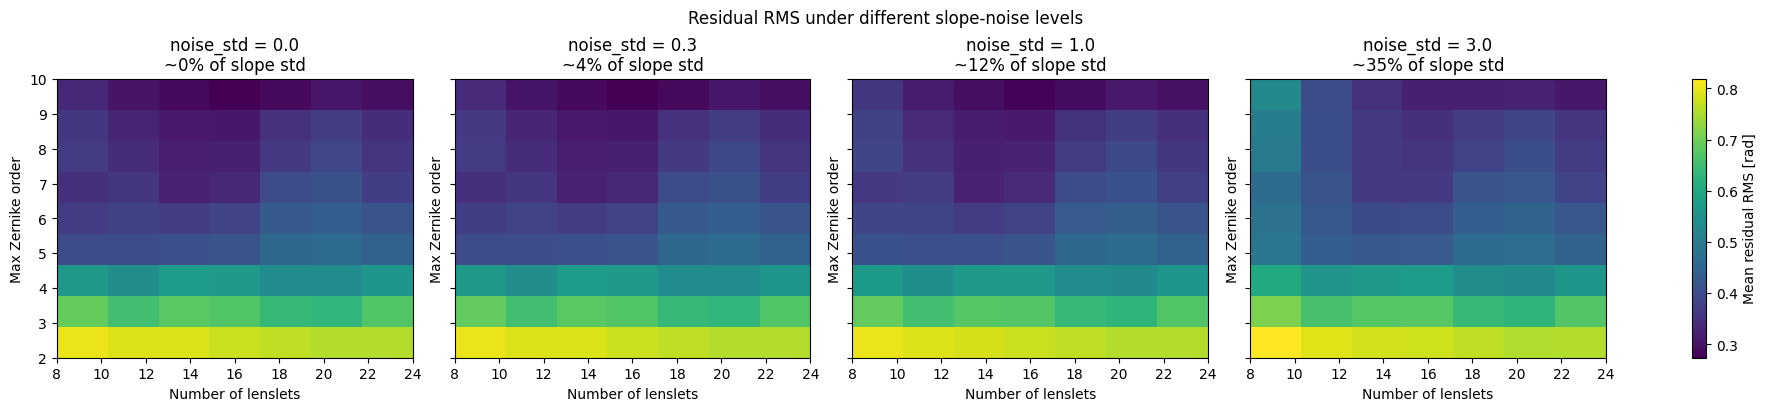

In [14]:
fig, axes = plt.subplots(
    1,
    len(noise_levels),
    figsize=(4.4 * len(noise_levels), 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

vmin = min(
    noise_results[ns]["residual_mean"].min()
    for ns in noise_levels
)
vmax = max(
    noise_results[ns]["residual_mean"].max()
    for ns in noise_levels
)

for ax, ns in zip(axes, noise_levels):
    residual_mean = noise_results[ns]["residual_mean"]

    im = ax.imshow(
        residual_mean,
        origin="lower",
        aspect="auto",
        extent=[
            lenslet_values[0],
            lenslet_values[-1],
            max_orders[0],
            max_orders[-1],
        ],
        vmin=vmin,
        vmax=vmax,
    )

    approx_rel_noise = 100 * ns / typical_slope_std

    ax.set_title(
        f"noise_std = {ns:.1f}\n"
        f"~{approx_rel_noise:.0f}% of slope std"
    )
    ax.set_xlabel("Number of lenslets")
    ax.set_ylabel("Max Zernike order")

fig.colorbar(im, ax=axes, label="Mean residual RMS [rad]")
fig.suptitle("Residual RMS under different slope-noise levels")

plt.show()

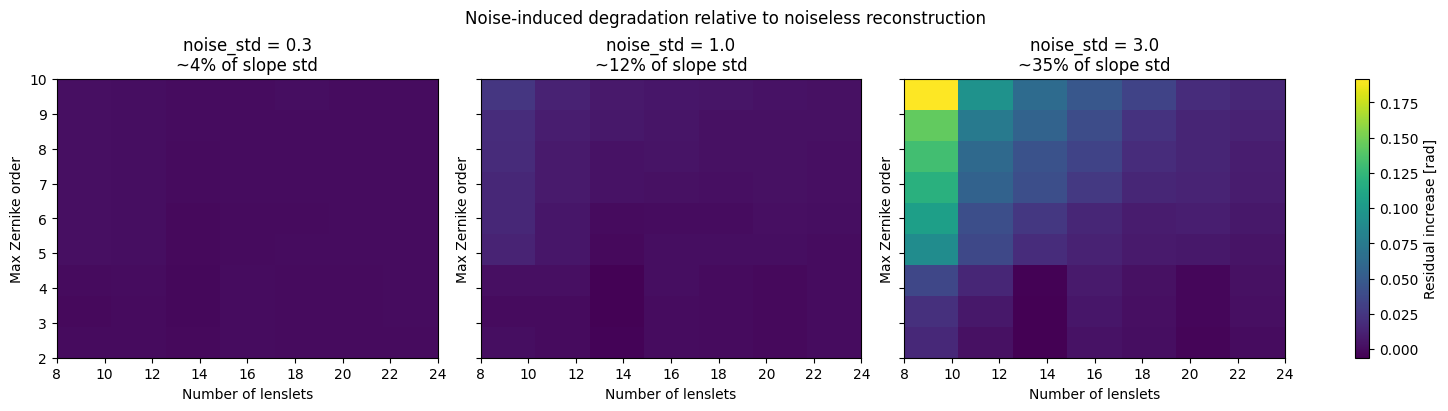

In [15]:
clean_residual = noise_results[0.0]["residual_mean"]

fig, axes = plt.subplots(
    1,
    len(noise_levels) - 1,
    figsize=(4.8 * (len(noise_levels) - 1), 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

# Use a common color scale for fair comparison.
degradation_maps = [
    noise_results[ns]["residual_mean"] - clean_residual
    for ns in noise_levels[1:]
]

vmin = min(d.min() for d in degradation_maps)
vmax = max(d.max() for d in degradation_maps)

for ax, ns, degradation in zip(axes, noise_levels[1:], degradation_maps):
    im = ax.imshow(
        degradation,
        origin="lower",
        aspect="auto",
        extent=[
            lenslet_values[0],
            lenslet_values[-1],
            max_orders[0],
            max_orders[-1],
        ],
        vmin=vmin,
        vmax=vmax,
    )

    approx_rel_noise = 100 * ns / typical_slope_std

    ax.set_title(
        f"noise_std = {ns:.1f}\n"
        f"~{approx_rel_noise:.0f}% of slope std"
    )
    ax.set_xlabel("Number of lenslets")
    ax.set_ylabel("Max Zernike order")

fig.colorbar(im, ax=axes, label="Residual increase [rad]")
fig.suptitle("Noise-induced degradation relative to noiseless reconstruction")

plt.show()

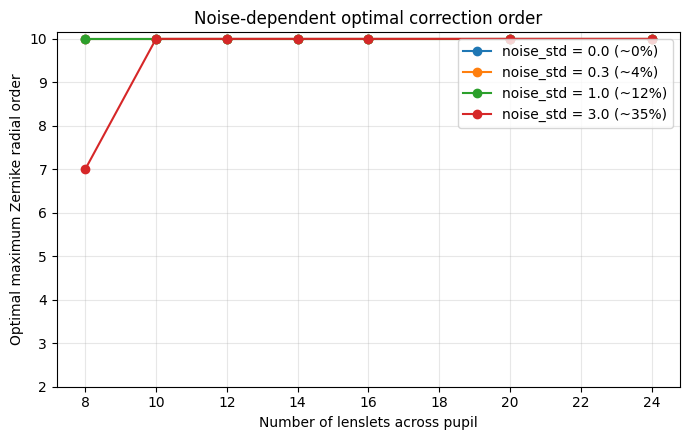

In [16]:
plt.figure(figsize=(7, 4.5))

for ns in noise_levels:
    residual_mean = noise_results[ns]["residual_mean"]

    # For each lenslet value, find the max_order that gives minimum residual RMS.
    best_order_indices = np.argmin(residual_mean, axis=0)
    best_orders = max_orders[best_order_indices]

    approx_rel_noise = 100 * ns / typical_slope_std

    plt.plot(
        lenslet_values,
        best_orders,
        marker="o",
        label=f"noise_std = {ns:.1f} (~{approx_rel_noise:.0f}%)",
    )

plt.xlabel("Number of lenslets across pupil")
plt.ylabel("Optimal maximum Zernike radial order")
plt.title("Noise-dependent optimal correction order")
plt.yticks(max_orders)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

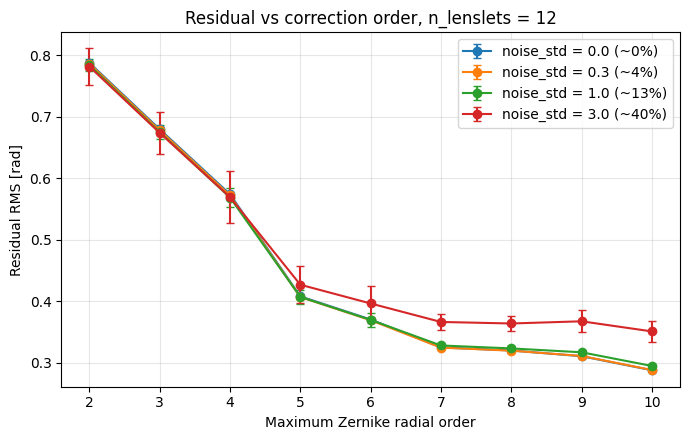

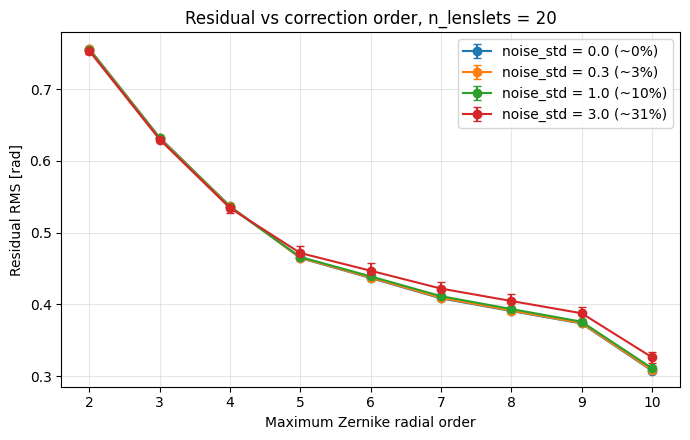

In [17]:
selected_lenslets = [12, 20]

for selected_lenslet in selected_lenslets:
    j = np.where(lenslet_values == selected_lenslet)[0][0]

    plt.figure(figsize=(7, 4.5))

    for ns in noise_levels:
        residual_mean = noise_results[ns]["residual_mean"][:, j]
        residual_std = noise_results[ns]["residual_std"][:, j]

        rel_noise = 100 * ns / slope_std_by_lenslet[selected_lenslet]

        plt.errorbar(
            max_orders,
            residual_mean,
            yerr=residual_std,
            marker="o",
            capsize=3,
            label=f"noise_std = {ns:.1f} (~{rel_noise:.0f}%)",
        )

    plt.xlabel("Maximum Zernike radial order")
    plt.ylabel("Residual RMS [rad]")
    plt.title(f"Residual vs correction order, n_lenslets = {selected_lenslet}")
    plt.xticks(max_orders)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [18]:
for nl in [8, 12, 20, 24]:
    centers, slopes_clean = measure_slopes(
        W_atm,
        mask,
        X,
        Y,
        n_lenslets=nl,
        min_fill=0.5,
        noise_std=0.0,
    )

    print(f"n_lenslets = {nl}")
    print("  slope std      =", np.std(slopes_clean))
    print("  mean |slope|   =", np.mean(np.abs(slopes_clean)))
    print("  max |slope|    =", np.max(np.abs(slopes_clean)))
    print()

n_lenslets = 8
  slope std      = 6.871184166133839
  mean |slope|   = 5.604100479975404
  max |slope|    = 20.418570995108855

n_lenslets = 12
  slope std      = 7.483657754453627
  mean |slope|   = 5.928331505676816
  max |slope|    = 24.312390653524606

n_lenslets = 20
  slope std      = 9.780957244252065
  mean |slope|   = 7.4521457903446
  max |slope|    = 46.78127374753882

n_lenslets = 24
  slope std      = 9.960085546021801
  mean |slope|   = 7.646179332524751
  max |slope|    = 56.33196576864013



In [19]:
nl = 12

_, slopes_clean = measure_slopes(
    W_atm,
    mask,
    X,
    Y,
    n_lenslets=nl,
    min_fill=0.5,
    noise_std=0.0,
)

for ns in [0.03, 0.1, 0.3, 1.0, 3.0]:
    _, slopes_noisy = measure_slopes(
        W_atm,
        mask,
        X,
        Y,
        n_lenslets=nl,
        min_fill=0.5,
        noise_std=ns,
        seed=1,
    )

    injected_noise = slopes_noisy - slopes_clean

    print(f"noise_std input = {ns}")
    print("  std(slopes_clean)      =", np.std(slopes_clean))
    print("  std(injected_noise)    =", np.std(injected_noise))
    print("  relative noise level   =", np.std(injected_noise) / np.std(slopes_clean))
    print()

noise_std input = 0.03
  std(slopes_clean)      = 7.483657754453627
  std(injected_noise)    = 0.027606581369799287
  relative noise level   = 0.0036889155377756596

noise_std input = 0.1
  std(slopes_clean)      = 7.483657754453627
  std(injected_noise)    = 0.09202193789933097
  relative noise level   = 0.012296385125918867

noise_std input = 0.3
  std(slopes_clean)      = 7.483657754453627
  std(injected_noise)    = 0.2760658136979929
  relative noise level   = 0.0368891553777566

noise_std input = 1.0
  std(slopes_clean)      = 7.483657754453627
  std(injected_noise)    = 0.9202193789933096
  relative noise level   = 0.12296385125918867

noise_std input = 3.0
  std(slopes_clean)      = 7.483657754453627
  std(injected_noise)    = 2.760658136979929
  relative noise level   = 0.36889155377756605



## Interpretation: Effect of slope-measurement noise

To interpret the noise levels physically, the clean Shack-Hartmann slope scale was first estimated. In this simulation, the clean slope standard deviation is approximately 7--10, depending on the number of lenslets across the pupil. Therefore, the absolute noise levels used in this scan correspond roughly to the following relative slope-noise levels:

* `noise_std = 0.3`: about 3--4% of the clean slope standard deviation
* `noise_std = 1.0`: about 10--13% of the clean slope standard deviation
* `noise_std = 3.0`: about 30--40% of the clean slope standard deviation

The residual RMS heatmaps show that low and moderate noise levels have only a weak effect on the reconstruction. For `noise_std = 0.3` and `noise_std = 1.0`, the residual RMS remains close to the noiseless case. This indicates that, in this regime, the dominant error source is still modal truncation error rather than slope-measurement noise. Increasing the maximum Zernike radial order allows the modal basis to represent more spatial structure of the atmospheric phase screen, which reduces the residual wavefront RMS.

At the strongest tested noise level, `noise_std = 3.0`, the effect of measurement noise becomes clearly visible. The degradation map shows that the largest residual increase occurs in the low-sampling and high-order region, especially for `n_lenslets = 8` and high maximum Zernike orders. This is consistent with the expectation that high-order modal reconstruction becomes more sensitive to slope noise when the Shack-Hartmann WFS is spatially undersampled.

The optimal-order plot confirms this behavior. Within the tested range, the highest reconstructed order remains optimal for most lenslet samplings. However, for the lowest sampling case, `n_lenslets = 8`, strong measurement noise reduces the optimal maximum radial order from 10 to approximately 7. This demonstrates the trade-off between modal fitting accuracy and noise amplification: increasing the correction order reduces fitting error, but in a noisy and undersampled regime, high-order modes can become less beneficial.

The fixed-lenslet residual curves further support this interpretation. For `n_lenslets = 12` and `n_lenslets = 20`, the residual RMS still generally decreases with increasing Zernike order, but the strong-noise case shows a systematic upward shift at higher orders. The effect is stronger for the lower-sampling case, while the denser lenslet sampling remains more robust.

Overall, this noise scan demonstrates that the maximum useful Zernike reconstruction order is not determined by the modal basis alone. It depends jointly on the wavefront sensor sampling, the measurement noise level, and the conditioning of the modal reconstruction problem.

This conclusion applies to the idealized slope-level model used here. In a detector-level SH-WFS, increasing the number of lenslets may reduce the photon flux per sub-aperture and can therefore worsen centroid accuracy under photon-noise-limited conditions.
